# Evidencia Estadística — Fabricante FAB3
## Emiliano Camacho Ponce A01712408


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import pearsonr

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

FAB_OBJETIVO = 'FAB3'


## 1. Carga y exploración inicial de los datos

In [ ]:
df = pd.read_excel('DATA_VENTAS.xlsx', sheet_name='datos')
print(df.shape)
df.head()


(3296, 15)


,CORTE,FABRICANTE,ID,PRODUCTO,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
0,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,14,4,2022-04-04,2022-04-01,"17,492.00",876,19.97,73,239.62,12
1,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,15,4,2022-04-11,2022-04-01,"53,364.90",2676,19.94,223,239.30,12
2,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,16,4,2022-04-18,2022-04-01,"75,747.96",3828,19.79,319,237.45,12
3,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,17,4,2022-04-25,2022-04-01,"73,193.36",3684,19.87,307,238.41,12
4,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,18,5,2022-05-02,2022-05-01,"94,031.14",4644,20.25,387,242.97,12


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3296 entries, 0 to 3295
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CORTE                    3296 non-null   str           
 1   FABRICANTE               3296 non-null   str           
 2   ID                       3296 non-null   str           
 3   PRODUCTO                 3296 non-null   str           
 4   AÑO1                     3296 non-null   int64         
 5   SEMANA                   3296 non-null   int64         
 6   MES                      3296 non-null   int64         
 7   FECHAW                   3296 non-null   datetime64[us]
 8   FECHAM                   3296 non-null   datetime64[us]
 9   VENTA_VALOR              3296 non-null   float64       
 10  LITROS                   3296 non-null   int64         
 11  PRECIO_UNITARIO_LITRO    3293 non-null   float64       
 12  PAQUETES                 3296 non-null   int6

In [ ]:
print('Fabricantes:', df['FABRICANTE'].unique())
print('Corte:', df['CORTE'].unique())
print('Rango de fechas (semana):', df['FECHAW'].min(), '->', df['FECHAW'].max())
print('Productos (ID) únicos:', df['ID'].nunique())


Fabricantes: <StringArray>
['FAB1', 'FAB2', 'FAB5', 'FAB6', 'FAB3']
Length: 5, dtype: str
Corte: <StringArray>
['TN']
Length: 1, dtype: str
Rango de fechas (semana): 2022-01-03 00:00:00 -> 2025-07-28 00:00:00
Productos (ID) únicos: 26


## 2. Limpieza de datos

### 2.1 Valores nulos

In [ ]:
nulls = df.isna().sum()
nulls[nulls > 0]


PRECIO_UNITARIO_LITRO      3
PRECIO_UNITARIO_PAQUETE    3
dtype: int64

In [ ]:
df[df['PRECIO_UNITARIO_LITRO'].isna()][['ID','FABRICANTE','FECHAW','VENTA_VALOR','LITROS','PAQUETES']]


,ID,FABRICANTE,FECHAW,VENTA_VALOR,LITROS,PAQUETES
1309,Leche Clasica Semi 1 L,FAB1,2024-04-15,0.00,192,16
1659,Des Light Deslactosada Light 1L,FAB2,2025-01-20,-268.00,0,0
3268,1L Ent Entera,FAB3,2025-04-21,0.00,0,0


Los 3 nulos en `PRECIO_UNITARIO_LITRO` / `PRECIO_UNITARIO_PAQUETE` ocurren en semanas con `LITROS = 0`
(o valores de venta prácticamente nulos/negativos, posiblemente devoluciones). El precio unitario no está
definido matemáticamente cuando no hay litros vendidos (división por cero), así que no se imputa un valor
arbitrario: se dejan como `NaN` y quedan naturalmente excluidos de cualquier promedio ponderado de precio
(`precio = Σventa / Σlitros`), ya que su contribución en litros es 0.

### 2.2 Duplicados a nivel de producto (mismo producto con distinto ID, o mismo ID con distinto nombre)

In [ ]:
# 1 mismo ID -> ¿más de un nombre de producto?
id_multi_nombre = df.groupby('ID')['PRODUCTO'].nunique()
print('IDs con más de un nombre de producto:', (id_multi_nombre > 1).sum())

# 1 mismo nombre de producto -> ¿más de un ID?
nombre_multi_id = df.groupby('PRODUCTO')['ID'].nunique()
print('Nombres de producto con más de un ID:', (nombre_multi_id > 1).sum())


IDs con más de un nombre de producto: 0
Nombres de producto con más de un ID: 0


No se encontraron inconsistencias: cada `ID` mapea a un único nombre de `PRODUCTO` y viceversa, y cada
producto pertenece siempre a un solo `FABRICANTE`. No hay que colapsar productos por este motivo.

### 2.3 Duplicados a nivel de fila (mismo producto, misma semana)

In [ ]:
dup_mask = df.duplicated(subset=['ID','FECHAW'], keep=False)
print('Filas involucradas en un ID+semana repetido:', dup_mask.sum())
df[dup_mask].sort_values(['ID','FECHAW']).head(6)[
    ['ID','FABRICANTE','FECHAW','MES','VENTA_VALOR','LITROS','PAQUETES']]


Filas involucradas en un ID+semana repetido: 556


,ID,FABRICANTE,FECHAW,MES,VENTA_VALOR,LITROS,PAQUETES
1629,Des Light Deslactosada Light 1L,FAB2,2024-10-07,10,"211,303.67",9336,778
1630,Des Light Deslactosada Light 1L,FAB2,2024-10-07,10,"8,397.00",396,33
1631,Des Light Deslactosada Light 1L,FAB2,2024-10-14,10,"210,346.78",10116,843
1632,Des Light Deslactosada Light 1L,FAB2,2024-10-14,10,"80,793.00",3924,327
1633,Des Light Deslactosada Light 1L,FAB2,2024-10-21,10,"40,552.91",1884,157
1634,Des Light Deslactosada Light 1L,FAB2,2024-10-21,10,"161,971.97",7716,643


Hay 278 combinaciones producto-semana con 2 registros. No son duplicados exactos (los valores de venta
y litros difieren), sino que corresponden a la misma referencia de producto reportada en más de una fila para
la misma semana (por ejemplo, distintos canales/presentaciones agregados en el archivo fuente bajo el mismo
`ID`). Para el análisis descriptivo y de series de tiempo, la unidad correcta de observación es
producto × semana, por lo que estas filas se colapsan sumando las variables de volumen (`VENTA_VALOR`,
`LITROS`, `PAQUETES`) y recalculando el precio unitario como venta/litros (precio ponderado por volumen, en
vez de promediar precios).

In [ ]:
df_clean = (
    df.groupby(['FABRICANTE','ID','PRODUCTO','FECHAW','FECHAM','AÑO1','MES','SEMANA'], as_index=False)
      .agg(VENTA_VALOR=('VENTA_VALOR','sum'),
           LITROS=('LITROS','sum'),
           PAQUETES=('PAQUETES','sum'))
)
df_clean['PRECIO_UNITARIO_LITRO'] = df_clean['VENTA_VALOR'] / df_clean['LITROS']

print('Filas antes:', len(df), '| Filas después de colapsar:', len(df_clean))
assert df_clean.duplicated(subset=['ID','FECHAW']).sum() == 0
df_clean.head()


Filas antes: 3296 | Filas después de colapsar: 3018


,FABRICANTE,ID,PRODUCTO,FECHAW,FECHAM,AÑO1,MES,SEMANA,VENTA_VALOR,LITROS,PAQUETES,PRECIO_UNITARIO_LITRO
0,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022-04-04,2022-04-01,2022,4,14,"17,492.00",876,73,19.97
1,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022-04-11,2022-04-01,2022,4,15,"53,364.90",2676,223,19.94
2,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022-04-18,2022-04-01,2022,4,16,"75,747.96",3828,319,19.79
3,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022-04-25,2022-04-01,2022,4,17,"73,193.36",3684,307,19.87
4,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022-05-02,2022-05-01,2022,5,18,"94,031.14",4644,387,20.25


`df_clean` queda en formato long, con una fila única por producto (`ID`) y semana
(`FECHAW`), que es la estructura adecuada para agregar por fabricante y para construir series de tiempo.

### 2.4 De semanal a mensual

**Retro atendida.** El archivo fuente viene a nivel producto-semana (`FECHAW`), pero el enunciado especifica
que se trabaja con **datos mensuales** ("historical monthly data") y toda la Parte 2 pide análisis y modelos
mensuales. En la entrega anterior, la parte descriptiva sí usaba una agregación mensual pero el modelo de
regresión se corrió sobre la serie semanal (187 observaciones) sin justificar el cambio de unidad de
observación, lo cual no es comparable con el resto del grupo ni con el enunciado. Aquí se construye una sola
tabla mensual (`mensual_todos`), en formato long, colapsando `df_clean` por producto (`ID`) y mes (`FECHAM`),
sumando volumen y valor y recalculando el precio como venta/litros (precio ponderado, no promedio simple de
precios semanales). Esta tabla mensual es la que se usa de aquí en adelante para todo el análisis descriptivo
**y** para los modelos de regresión.

In [ ]:
mensual_todos = (
    df_clean.groupby(['FABRICANTE','ID','PRODUCTO','AÑO1','MES','FECHAM'], as_index=False)
            .agg(VENTA_VALOR=('VENTA_VALOR','sum'), LITROS=('LITROS','sum'), PAQUETES=('PAQUETES','sum'))
)
mensual_todos['PRECIO_UNITARIO_LITRO'] = mensual_todos['VENTA_VALOR'] / mensual_todos['LITROS']
mensual_todos['log_LITROS'] = np.log(mensual_todos['LITROS'])
mensual_todos['log_PRECIO'] = np.log(mensual_todos['PRECIO_UNITARIO_LITRO'])
mensual_todos = mensual_todos.sort_values(['ID','FECHAM']).reset_index(drop=True)

print('Filas mensuales (producto-mes):', len(mensual_todos),
      '| Meses distintos:', mensual_todos['FECHAM'].nunique(),
      '| Productos distintos:', mensual_todos['ID'].nunique())
mensual_todos.head()


Filas mensuales (producto-mes): 710 | Meses distintos: 43 | Productos distintos: 26


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,FABRICANTE,ID,PRODUCTO,AÑO1,MES,FECHAM,VENTA_VALOR,LITROS,PAQUETES,PRECIO_UNITARIO_LITRO,log_LITROS,log_PRECIO
0,FAB2,100 70+30,FAB2_ 100 70+30,2022,1,2022-01-01,271.00,12,1,22.58,2.48,3.12
1,FAB2,100 Low C Arb,FAB2_ 100 Low C Arb,2023,11,2023-11-01,"402,512.89",17988,1499,22.38,9.80,3.11
2,FAB2,100 Low C Arb,FAB2_ 100 Low C Arb,2023,12,2023-12-01,"623,084.68",29664,2472,21.00,10.30,3.04
3,FAB2,100 Low C Arb,FAB2_ 100 Low C Arb,2024,1,2024-01-01,"679,620.91",30300,2525,22.43,10.32,3.11
4,FAB2,100 Low C Arb,FAB2_ 100 Low C Arb,2024,2,2024-02-01,"845,147.81",38076,3173,22.20,10.55,3.10


In [ ]:
# Verificación: ¿cuántas semanas ISO agrupa cada mes (FECHAM)?
semanas_por_mes = df[['FECHAM','FECHAW']].drop_duplicates().groupby('FECHAM')['FECHAW'].nunique()
print(semanas_por_mes.value_counts().rename('cantidad_de_meses'))
print(f"Meses con 5 semanas: {(semanas_por_mes==5).sum()} de {len(semanas_por_mes)} meses totales")


FECHAW
4    28
5    15
Name: cantidad_de_meses, dtype: int64
Meses con 5 semanas: 15 de 43 meses totales


Hay 15 meses de 5 semanas ISO y 28 de 4 semanas. Esto infla la venta y el volumen reportado de los meses
de 5 semanas sin que sea necesariamente un cambio real en la demanda. No se normaliza esta columna, pero se
documenta como una limitación a tener en cuenta al comparar meses individuales entre sí (afecta más a la
lectura mes a mes que a los promedios anuales o a la regresión, que usa log-diferencias relativas).

## 3. Market share por fabricante

### 3.1 Composición del market share por año (venta $ y volumen litros)

In [ ]:
share_year_val = (mensual_todos.groupby(['AÑO1','FABRICANTE'])['VENTA_VALOR'].sum()
                  .reset_index())
share_year_val['SHARE'] = (share_year_val['VENTA_VALOR']
                            / share_year_val.groupby('AÑO1')['VENTA_VALOR'].transform('sum'))
share_pivot_val = share_year_val.pivot(index='FABRICANTE', columns='AÑO1', values='SHARE')

print('Market share por año — % de VENTA ($)')
display(share_pivot_val.style.format('{:.1%}', na_rep='-'))


Market share por año — % de VENTA ($)


AÑO1,2022,2023,2024,2025
FABRICANTE,,,,
FAB1,44.6%,46.4%,41.4%,33.7%
FAB2,21.0%,22.6%,20.7%,11.6%
FAB3,31.4%,28.9%,31.5%,28.0%
FAB5,-,-,6.3%,26.7%
FAB6,2.9%,2.0%,0.0%,-


**Retro atendida.** El share en valor por sí solo no distingue si un fabricante gana mercado vendiendo más
litros o solo subiendo precio. Se agrega el share en **volumen (litros)**, que junto con el de valor revela el
posicionamiento de precio de cada fabricante.

In [ ]:
share_year_vol = (mensual_todos.groupby(['AÑO1','FABRICANTE'])['LITROS'].sum()
                  .reset_index())
share_year_vol['SHARE'] = (share_year_vol['LITROS']
                            / share_year_vol.groupby('AÑO1')['LITROS'].transform('sum'))
share_pivot_vol = share_year_vol.pivot(index='FABRICANTE', columns='AÑO1', values='SHARE')

print('Market share por año — % de VOLUMEN (litros)')
display(share_pivot_vol.style.format('{:.1%}', na_rep='-'))


Market share por año — % de VOLUMEN (litros)


AÑO1,2022,2023,2024,2025
FABRICANTE,,,,
FAB1,43.8%,46.2%,41.2%,33.0%
FAB2,22.3%,23.8%,21.0%,10.1%
FAB3,30.3%,27.6%,30.5%,26.8%
FAB5,-,-,7.3%,30.1%
FAB6,3.6%,2.4%,0.0%,-


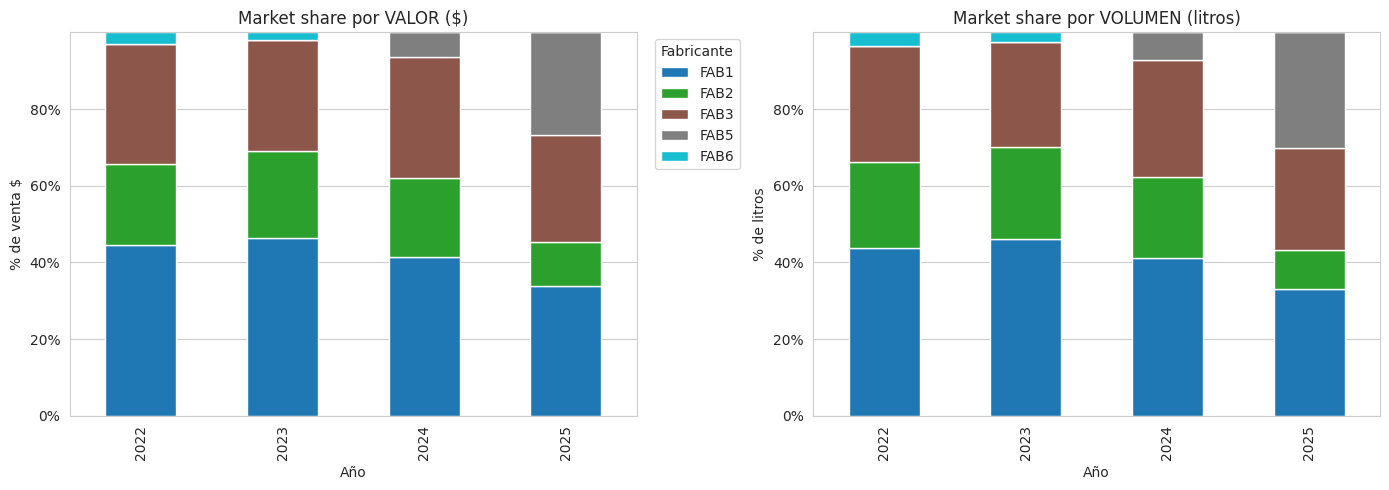

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

share_pivot_val.T.plot(kind='bar', stacked=True, colormap='tab10', ax=axes[0])
axes[0].set_title('Market share por VALOR ($)')
axes[0].set_ylabel('% de venta $')
axes[0].set_xlabel('Año')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend(title='Fabricante', bbox_to_anchor=(1.02,1), loc='upper left')

share_pivot_vol.T.plot(kind='bar', stacked=True, colormap='tab10', ax=axes[1], legend=False)
axes[1].set_title('Market share por VOLUMEN (litros)')
axes[1].set_ylabel('% de litros')
axes[1].set_xlabel('Año')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig('share_por_anio.png', dpi=120)
plt.show()


FAB1 es el líder de la categoría todo el periodo (34%-46% en valor y en volumen), seguido de FAB3, cuya
participación se mantiene relativamente estable (28%-31% tanto en valor como en volumen). FAB2 pierde
participación de forma sostenida (de 21-23% hasta 10-12% en 2025). FAB5 es un entrante que aparece en 2024
y crece rápidamente hasta 27% de valor y **~30% de volumen** en 2025, mientras que FAB6 prácticamente
desaparece.

**Lectura conjunta valor vs. volumen — posicionamiento de precio.** En 2025, FAB5 vende **más volumen (30.1%)
del que factura en valor (26.7%)**, es decir, su participación de mercado es más grande en litros que en
pesos. Eso solo es posible si su precio por litro está por debajo del promedio de la categoría: con los
datos del último año (sección 3.2 más abajo) el precio ponderado de FAB5 es de **\$19.31/L**, claramente por
debajo de FAB1 (\$22.29), FAB3 (\$22.93) y FAB2 (\$23.81). FAB5 no le está quitando mercado a FAB2 por mejor
producto sino por **precio de entrada**, lo cual es consistente con la caída simultánea del share de FAB2.

### 3.2 Top fabricantes que concentran el 80% del market share en los últimos 12 meses

In [ ]:
max_mes = mensual_todos['FECHAM'].max()
fecha_corte = max_mes - pd.DateOffset(months=11)
print(f'Últimos 12 meses (calendario, mensual): {fecha_corte.date()} a {max_mes.date()}')

last12 = mensual_todos[mensual_todos['FECHAM'] >= fecha_corte]

share_l12 = (last12.groupby('FABRICANTE')['VENTA_VALOR'].sum()
             .sort_values(ascending=False))
share_l12_pct = (share_l12 / share_l12.sum()).rename('share')
tabla_80 = pd.concat([share_l12.rename('venta_$'), share_l12_pct,
                       share_l12_pct.cumsum().rename('share_acum')], axis=1)
tabla_80['top_80'] = tabla_80['share_acum'].shift(1, fill_value=0) < 0.80
display(tabla_80.style.format({'venta_$':'{:,.0f}', 'share':'{:.1%}', 'share_acum':'{:.1%}'}))


Últimos 12 meses (calendario, mensual): 2024-08-01 a 2025-07-01


,venta_$,share,share_acum,top_80
FABRICANTE,,,,
FAB1,"255,391,705",35.9%,35.9%,True
FAB3,"204,099,369",28.7%,64.6%,True
FAB5,"156,370,728",22.0%,86.6%,True
FAB2,"94,889,541",13.4%,100.0%,False


In [ ]:
top80 = tabla_80[tabla_80['top_80']].index.tolist()
print('Fabricantes que concentran el 80% del mercado (últimos 12 meses):', top80)
print(f'Cobertura acumulada: {tabla_80.loc[top80, "share_acum"].iloc[-1]:.1%}')


Fabricantes que concentran el 80% del mercado (últimos 12 meses): ['FAB1', 'FAB3', 'FAB5']
Cobertura acumulada: 86.6%


En los últimos 12 meses disponibles (con corte mensual: ago-2024 a jul-2025), se necesitan **FAB1, FAB3
y FAB5** para alcanzar el 80% del market share de la categoría (86.65% acumulado). FAB3, el fabricante
objetivo de este análisis, es el segundo más importante de la categoría, con **28.7%** del mercado en el
último año. El mismo cálculo en volumen (litros) da el mismo trío de fabricantes con 87.7% acumulado, aunque
con FAB5 un poco más adelante (24.96% vs 22.00% en valor), reforzando la lectura de la sección 3.1: FAB5 gana
más terreno en volumen que en valor.

**Retro atendida — descriptivos comparables entre fabricantes.** Además de los descriptivos de FAB3, se
muestra una tabla comparable de los 4 fabricantes activos en los últimos 12 meses (venta y volumen totales,
precio ponderado, dispersión del precio mensual y número de productos activos), que es la que sustenta la
lectura de posicionamiento de precio de la sección 3.1.

In [ ]:
desc_fab = (last12.groupby('FABRICANTE')
            .apply(lambda d: pd.Series({
                'venta_total_12m': d['VENTA_VALOR'].sum(),
                'litros_total_12m': d['LITROS'].sum(),
                'precio_prom_ponderado': d['VENTA_VALOR'].sum()/d['LITROS'].sum(),
                'precio_min_mensual': d.groupby('FECHAM').apply(
                    lambda x: x['VENTA_VALOR'].sum()/x['LITROS'].sum(), include_groups=False).min(),
                'precio_max_mensual': d.groupby('FECHAM').apply(
                    lambda x: x['VENTA_VALOR'].sum()/x['LITROS'].sum(), include_groups=False).max(),
                'n_productos_activos': d['ID'].nunique(),
            }), include_groups=False)
            .sort_values('venta_total_12m', ascending=False))
display(desc_fab.style.format({'venta_total_12m':'{:,.0f}', 'litros_total_12m':'{:,.0f}',
                                'precio_prom_ponderado':'{:.2f}', 'precio_min_mensual':'{:.2f}',
                                'precio_max_mensual':'{:.2f}', 'n_productos_activos':'{:.0f}'}))


,venta_total_12m,litros_total_12m,precio_prom_ponderado,precio_min_mensual,precio_max_mensual,n_productos_activos
FABRICANTE,,,,,,
FAB1,"255,391,705","11,456,052",22.29,21.52,23.66,8
FAB3,"204,099,369","8,902,608",22.93,21.99,24.24,3
FAB5,"156,370,728","8,098,848",19.31,17.69,20.38,3
FAB2,"94,889,541","3,984,552",23.81,21.76,26.27,7


FAB1 y FAB3 sostienen un rango de precio similar (\$22-23/L) con portafolios amplios (7-8 productos
activos para FAB1, aunque solo 3 para FAB3). FAB2, el fabricante que más participación ha perdido, es en
realidad el de **precio más alto** (\$23.81/L) y con el portafolio más amplio (7 productos), consistente con
que está perdiendo volumen frente a la oferta de menor precio de FAB5 (\$19.31/L) y no por falta de variedad
de producto.

## 4. Desempeño de ventas y precio en el tiempo — FAB3

In [ ]:
f3 = mensual_todos[mensual_todos['FABRICANTE'] == FAB_OBJETIVO].copy()
print('Productos de FAB3:', f3['PRODUCTO'].unique())
print('Observaciones (producto-mes):', len(f3))
f3.describe()


Productos de FAB3: <StringArray>
['FAB3_1L  D Li Deslactosada Light',       'FAB3_1L  Desl Deslactosada',
              'FAB3_1L  Ent Entera']
Length: 3, dtype: str
Observaciones (producto-mes): 129


,AÑO1,MES,FECHAM,VENTA_VALOR,LITROS,PAQUETES,PRECIO_UNITARIO_LITRO,log_LITROS,log_PRECIO
count,129.00,129.00,129,129.00,129.00,129.00,129.00,129.00,129.00
mean,"2,023.33",6.09,2023-10-01 07:48:50.232558,"5,359,086.79","255,280.28","21,273.36",21.32,12.20,3.06
min,"2,022.00",1.00,2022-01-01 00:00:00,"1,034,818.98","55,116.00","4,593.00",17.78,10.92,2.88
25%,"2,022.00",3.00,2022-11-01 00:00:00,"1,932,433.18","88,200.00","7,350.00",20.01,11.39,3.00
50%,"2,023.00",6.00,2023-10-01 00:00:00,"5,304,993.82","247,740.00","20,645.00",21.03,12.42,3.05
75%,"2,024.00",9.00,2024-09-01 00:00:00,"7,836,070.75","356,316.00","29,693.00",22.75,12.78,3.12
max,"2,025.00",12.00,2025-07-01 00:00:00,"13,341,026.07","725,052.00","60,421.00",25.04,13.49,3.22
std,1.05,3.40,NaN,"3,268,066.82","162,313.02","13,526.08",1.69,0.75,0.08


In [ ]:
# Serie mensual agregada de FAB3 (venta $, litros, precio promedio ponderado por litro)
mensual = (f3.groupby('FECHAM', as_index=False)
             .agg(VENTA_VALOR=('VENTA_VALOR','sum'), LITROS=('LITROS','sum')))
mensual['PRECIO_PROM_LITRO'] = mensual['VENTA_VALOR'] / mensual['LITROS']
mensual.tail()


,FECHAM,VENTA_VALOR,LITROS,PRECIO_PROM_LITRO
38,2025-03-01,"16,363,767.18",723900,22.61
39,2025-04-01,"13,180,208.44",548568,24.03
40,2025-05-01,"20,242,081.94",864972,23.40
41,2025-06-01,"12,024,484.49",496008,24.24
42,2025-07-01,"19,927,821.66",877284,22.72


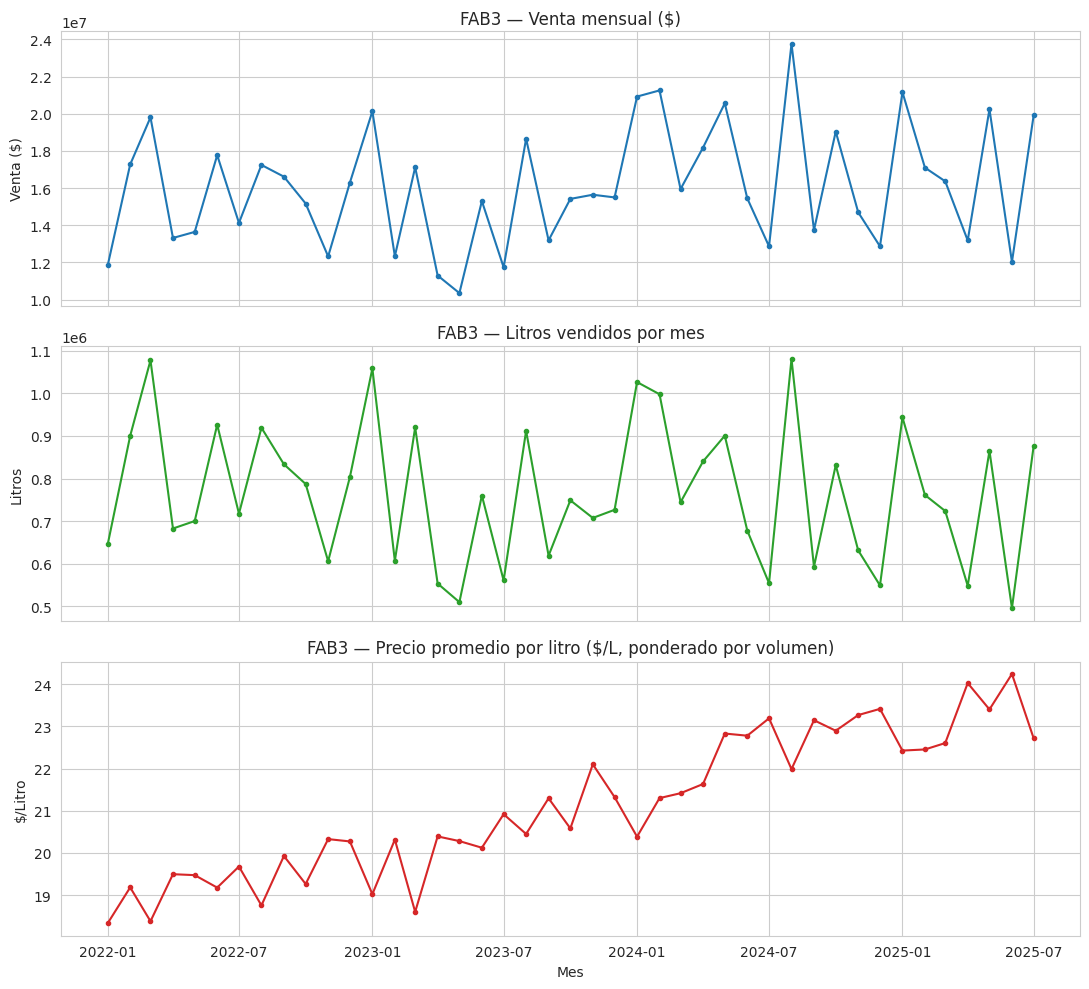

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(11,10), sharex=True)

axes[0].plot(mensual['FECHAM'], mensual['VENTA_VALOR'], color='tab:blue', marker='o', ms=3)
axes[0].set_title(f'{FAB_OBJETIVO} — Venta mensual ($)')
axes[0].set_ylabel('Venta ($)')

axes[1].plot(mensual['FECHAM'], mensual['LITROS'], color='tab:green', marker='o', ms=3)
axes[1].set_title(f'{FAB_OBJETIVO} — Litros vendidos por mes')
axes[1].set_ylabel('Litros')

axes[2].plot(mensual['FECHAM'], mensual['PRECIO_PROM_LITRO'], color='tab:red', marker='o', ms=3)
axes[2].set_title(f'{FAB_OBJETIVO} — Precio promedio por litro ($/L, ponderado por volumen)')
axes[2].set_ylabel('$/Litro')
axes[2].set_xlabel('Mes')

plt.tight_layout()
plt.savefig('fab3_series_tiempo.png', dpi=120)
plt.show()


In [ ]:
# Estadística descriptiva por producto de FAB3 (todo el periodo, base mensual)
desc_prod = f3.groupby('PRODUCTO').agg(
    venta_total=('VENTA_VALOR','sum'),
    litros_total=('LITROS','sum'),
    precio_prom=('PRECIO_UNITARIO_LITRO','mean'),
    precio_std=('PRECIO_UNITARIO_LITRO','std'),
    n_meses=('FECHAM','nunique')
).sort_values('venta_total', ascending=False)
desc_prod['share_dentro_fab3'] = desc_prod['venta_total'] / desc_prod['venta_total'].sum()
display(desc_prod.style.format({'venta_total':'{:,.0f}', 'litros_total':'{:,.0f}',
                         'precio_prom':'{:.2f}', 'precio_std':'{:.2f}', 'share_dentro_fab3':'{:.1%}'}))


,venta_total,litros_total,precio_prom,precio_std,n_meses,share_dentro_fab3
PRODUCTO,,,,,,
FAB3_1L Ent Entera,"383,779,127","18,567,048",20.92,1.76,43,55.5%
FAB3_1L Desl Deslactosada,"235,076,991","11,050,824",21.28,1.51,43,34.0%
FAB3_1L D Li Deslactosada Light,"72,466,078","3,313,284",21.76,1.73,43,10.5%


- El producto "Ent Entera" (leche entera) es el que más aporta a las ventas de FAB3, seguido de
  "Desl Deslactosada"; el producto light/deslactosado light tiene una participación menor dentro del
  portafolio.
- Las ventas de FAB3 muestran una tendencia de crecimiento moderada en el tiempo, con estacionalidad visible
  (caídas hacia fin de año / diciembre).
- El precio promedio por litro muestra una tendencia ascendente sostenida a lo largo del periodo (de 18-19 en
  2022 a 22-24 en 2025), consistente con inflación/ajustes de precio de la categoría.
- Los litros vendidos son más volátiles mes a mes que la venta en $, lo que sugiere que parte de la
  variación en ventas responde a cambios de precio y no solo de volumen.

### 4.3 Producto top de FAB3 en los últimos 12 meses

In [ ]:
# Mismo corte de últimos 12 meses usado en la sección 3.2, aplicado ahora solo a FAB3
last12_f3 = f3[f3['FECHAM'] >= fecha_corte]

top_prod_u12m = (last12_f3.groupby('PRODUCTO')['VENTA_VALOR'].sum()
                 .sort_values(ascending=False))
top_prod_u12m_share = (top_prod_u12m / top_prod_u12m.sum()).rename('share_u12m')
display(pd.concat([top_prod_u12m.rename('venta_$_u12m'), top_prod_u12m_share], axis=1)
        .style.format({'venta_$_u12m':'{:,.0f}', 'share_u12m':'{:.1%}'}))

PRODUCTO_TOP = top_prod_u12m.index[0]
print(f'Producto top de FAB3 en los últimos 12 meses: {PRODUCTO_TOP!r} '
      f'({top_prod_u12m_share.iloc[0]:.1%} de la venta $ de FAB3 en el periodo)')


,venta_$_u12m,share_u12m
PRODUCTO,,
FAB3_1L Ent Entera,"104,986,911",51.4%
FAB3_1L Desl Deslactosada,"75,355,812",36.9%
FAB3_1L D Li Deslactosada Light,"23,756,645",11.6%


Producto top de FAB3 en los últimos 12 meses: 'FAB3_1L  Ent Entera' (51.4% de la venta $ de FAB3 en el periodo)


En los últimos 12 meses disponibles, **`1L Ent Entera` (leche entera)** es el producto que más aporta a
la venta de FAB3 (51.4%), muy por encima de `Desl Deslactosada` (36.9%) y de `D Li Deslactosada Light`
(11.6%). Es, por lo tanto, el producto que se usa como "producto top de FAB3" para el modelo de regresión de
la sección 6.

## 5. Objetivo 2 — Análisis de correlación

El objetivo 2 pide un análisis de correlación inicial para entender relaciones importantes dentro de
los datos. Se construyen tres bloques de correlación, cada uno respondiendo una pregunta distinta:

1. **Correlación general (esta sección)**: matriz de Pearson sobre las variables numéricas a nivel
   producto-mes (`PRECIO_UNITARIO_LITRO`, `LITROS`, `VENTA_VALOR`, `PAQUETES` y sus logs) — sirve para
   detectar redundancias mecánicas entre variables antes de modelar.
2. **Precio vs. volumen del producto top de FAB3** — confirma numéricamente, en la misma transformación
   log-log que usa la regresión de la sección 6, la dirección de la relación que después estima el modelo.
3. **Correlación ENTRE fabricantes competidores (sección 5.3)** — responde una pregunta de negocio directa
   ("¿se mueven los precios/volúmenes de los competidores juntos?") y condiciona el diseño del modelo de
   elasticidad cruzada de la sección 7.

In [ ]:
cols_corr = ['PRECIO_UNITARIO_LITRO','LITROS','VENTA_VALOR','PAQUETES','log_PRECIO','log_LITROS']
corr_matrix = mensual_todos[cols_corr].corr(method='pearson')
display(corr_matrix.style.format('{:.2f}').background_gradient(cmap='RdBu_r', vmin=-1, vmax=1))


,PRECIO_UNITARIO_LITRO,LITROS,VENTA_VALOR,PAQUETES,log_PRECIO,log_LITROS
PRECIO_UNITARIO_LITRO,1.00,-0.20,-0.13,-0.20,0.92,-0.15
LITROS,-0.20,1.00,0.99,1.00,-0.13,0.69
VENTA_VALOR,-0.13,0.99,1.00,0.99,-0.06,0.69
PAQUETES,-0.20,1.00,0.99,1.00,-0.12,0.69
log_PRECIO,0.92,-0.13,-0.06,-0.12,1.00,-0.02
log_LITROS,-0.15,0.69,0.69,0.69,-0.02,1.00


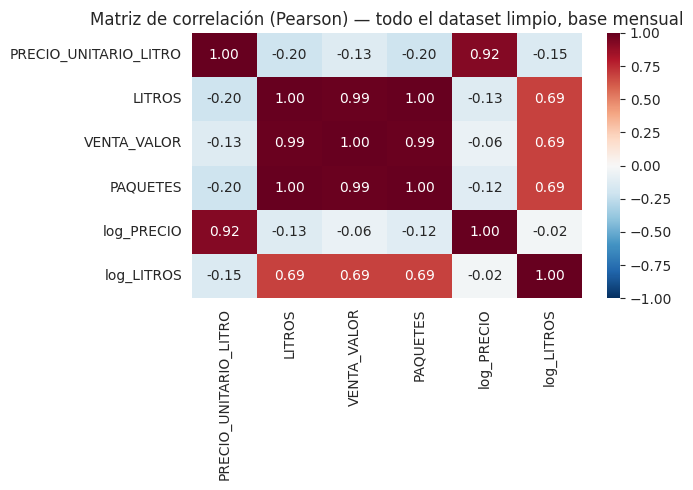

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, ax=ax)
ax.set_title('Matriz de correlación (Pearson) — todo el dataset limpio, base mensual')
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=120)
plt.show()


**Interpretación.**
- `LITROS` y `PAQUETES` están correlacionados de forma prácticamente perfecta (r ≈ 1.00), lo cual es
  esperado, ya que ambos miden volumen físico vendido a través de `UNIDADES_EN_PAQUETE`, así que aportan la
  misma información y para el modelado basta con usar una de las dos (se usa `LITROS`, unidad común entre
  productos de distinto tamaño de empaque).
- `VENTA_VALOR` y `LITROS` están fuertemente correlacionados (r ≈ 0.99), como es de esperarse porque la
  venta en pesos es, por construcción, precio × volumen y el volumen domina esa relación.
- Estas dos son redundancias mecánicas, no hallazgos de negocio: no controlan por producto, mes, tendencia
  u otra variable, por lo que son un análisis exploratorio y no reemplazan la regresión, que sí aísla el
  efecto del precio manteniendo fijo un producto específico y lo controla estadísticamente (t, p-value,
  intervalos de confianza).

Como complemento, se muestra la relación precio-volumen específicamente para el producto top de FAB3
(`1L Ent Entera`) a nivel **mensual**, con su coeficiente de correlación de Pearson anotado.

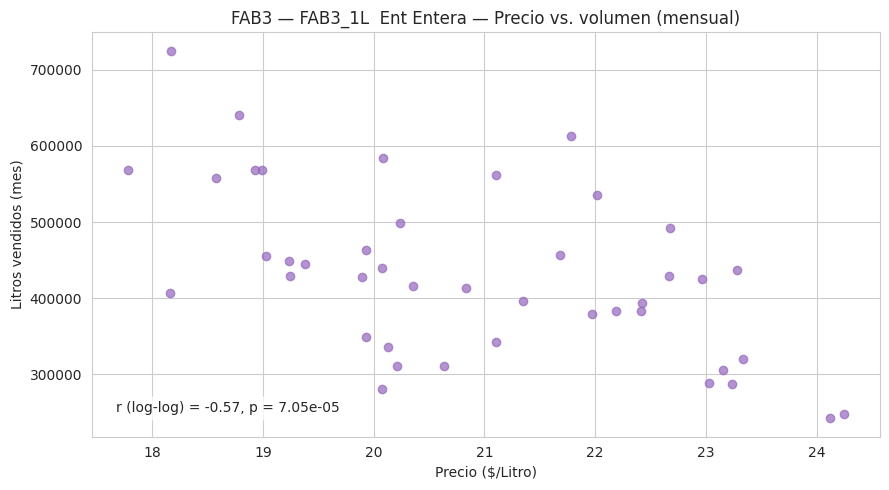

Correlación (log-log) precio vs. litros, FAB3_1L  Ent Entera: r = -0.568, p = 7.05e-05


In [ ]:
top = mensual_todos[(mensual_todos['FABRICANTE'] == FAB_OBJETIVO) &
                     (mensual_todos['PRODUCTO'] == PRODUCTO_TOP)].copy()
top = top[top['LITROS'] > 0].sort_values('FECHAM').reset_index(drop=True)
top['PRECIO'] = top['PRECIO_UNITARIO_LITRO']

r_top, p_top = pearsonr(top['log_PRECIO'], top['log_LITROS'])

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.scatter(top['PRECIO'], top['LITROS'], alpha=0.7, color='tab:purple')
ax1.set_xlabel('Precio ($/Litro)')
ax1.set_ylabel('Litros vendidos (mes)')
ax1.set_title(f'{FAB_OBJETIVO} — {PRODUCTO_TOP} — Precio vs. volumen (mensual)')
ax1.text(0.03, 0.06, f'r (log-log) = {r_top:.2f}, p = {p_top:.2e}',
          transform=ax1.transAxes, fontsize=10,
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig('scatter_precio_litros_top.png', dpi=120)
plt.show()

print(f'Correlación (log-log) precio vs. litros, {PRODUCTO_TOP}: r = {r_top:.3f}, p = {p_top:.2e}')


El signo negativo (r = -0.57, p < 0.001) confirma numéricamente la relación inversa entre precio y
volumen que se estima formalmente en la sección 6, y es la misma transformación log-log que usa esa
regresión, así que el coeficiente de correlación es directamente comparable con el resultado del modelo.

### 5.3 Correlación ENTRE fabricantes competidores


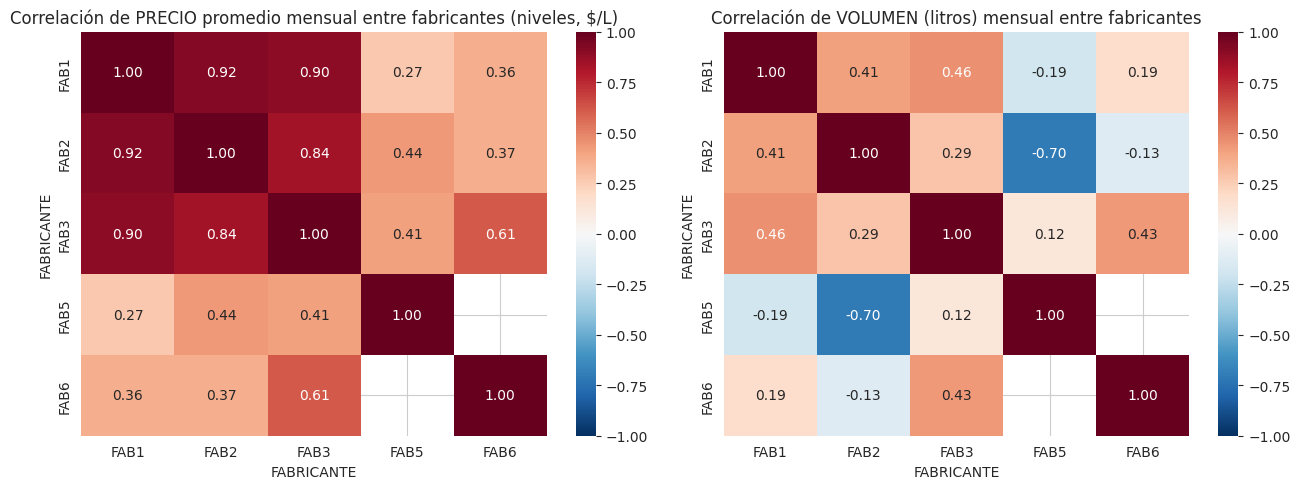

In [ ]:
precio_fab_wide = (mensual_todos.groupby(['FECHAM','FABRICANTE'])
                    .apply(lambda d: d['VENTA_VALOR'].sum()/d['LITROS'].sum(), include_groups=False)
                    .unstack('FABRICANTE'))
litros_fab_wide = mensual_todos.groupby(['FECHAM','FABRICANTE'])['LITROS'].sum().unstack('FABRICANTE')

corr_precio_fab = precio_fab_wide.corr()
corr_litros_fab = litros_fab_wide.corr()

fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.heatmap(corr_precio_fab, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlación de PRECIO promedio mensual entre fabricantes (niveles, $/L)')
sns.heatmap(corr_litros_fab, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlación de VOLUMEN (litros) mensual entre fabricantes')
plt.tight_layout()
plt.savefig('corr_entre_fabricantes.png', dpi=120)
plt.show()


In [ ]:
# Misma correlación de precio pero sobre el % de cambio mes a mes (elimina la tendencia común de inflación)
pct_change_precio = precio_fab_wide[['FAB1','FAB2','FAB3']].pct_change().dropna()
print('Correlación de precio en % de cambio mensual (FAB1, FAB2, FAB3):')
display(pct_change_precio.corr().round(2))


Correlación de precio en % de cambio mensual (FAB1, FAB2, FAB3):


FABRICANTE,FAB1,FAB2,FAB3
FABRICANTE,,,
FAB1,1.00,0.25,0.11
FAB2,0.25,1.00,-0.17
FAB3,0.11,-0.17,1.00


**Precio entre competidores.** FAB1, FAB2 y FAB3 (los incumbentes con mayor historia) tienen precios
correlacionados en niveles entre **0.84 y 0.92**. A primera vista parecería que compiten en precio de forma
coordinada, pero al quitar la tendencia común (correlacionando el % de cambio mes a mes en vez del precio en
niveles), la correlación cae drásticamente a 0.11-0.25. Esto muestra que los tres precios suben con el
tiempo por **inflación de categoría común**, no porque un fabricante reaccione activamente al precio del
otro mes a mes. La implicación directa para el modelo de la sección 7 es que meter los precios de los
competidores **en niveles** como variables explicativas generaría alta multicolinealidad (ver sección 7).

**Volumen entre competidores.** El hallazgo más informativo aparece en **FAB2 vs. FAB5, con r = -0.70**: a
medida que FAB5 gana volumen, FAB2 lo pierde de forma casi simétrica, consistente con la lectura de la
sección 3.1 (FAB5 entra con precio más bajo y le quita volumen a FAB2, el fabricante de mayor precio de la
categoría). El resto de los pares de fabricantes tienen correlaciones de volumen mucho más débiles o
positivas, lo que sugiere que la competencia por volumen en esta categoría es especialmente intensa entre
esos dos fabricantes específicos y no un fenómeno generalizado entre todos.

## 6. Modelo de regresión — producto top de FAB3

**Retro atendida — granularidad.** El modelo se corre ahora sobre la serie **mensual** del producto top de
FAB3 (`1L Ent Entera`), que es la unidad de análisis que pide el enunciado ("historical monthly data") y la
misma que se usó en toda la parte descriptiva. En la entrega anterior este modelo se corrió sobre 187
observaciones semanales sin justificar el cambio de granularidad frente al resto del análisis.

Se usa un modelo **log-log** (`log(litros) ~ log(precio)`), en el que el coeficiente de `log(precio)` se
interpreta directamente como la **elasticidad precio de la demanda**. Solo se usa el precio como variable
explicativa, tal como pide el objetivo 3 (sin estacionalidad ni tendencia todavía).

In [ ]:
mensual_top = top.copy()  # construido en la sección 5 para el producto top de FAB3, base mensual
print(mensual_top.shape)
mensual_top[['FECHAM','PRECIO','LITROS','log_PRECIO','log_LITROS']].head()


(43, 13)


,FECHAM,PRECIO,LITROS,log_PRECIO,log_LITROS
0,2022-01-01,18.16,406992,2.90,12.92
1,2022-02-01,18.99,567936,2.94,13.25
2,2022-03-01,18.17,725052,2.90,13.49
3,2022-04-01,19.23,448704,2.96,13.01
4,2022-05-01,19.24,429408,2.96,12.97


In [ ]:
modelo = smf.ols('log_LITROS ~ log_PRECIO', data=mensual_top).fit()
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:             log_LITROS   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.306
Method:                 Least Squares   F-statistic:                     19.55
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           7.05e-05
Time:                        01:31:53   Log-Likelihood:                 5.6528
No. Observations:                  43   AIC:                            -7.306
Df Residuals:                      41   BIC:                            -3.783
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     18.3054      1.213     15.088      0.0

In [ ]:
from statsmodels.stats.stattools import durbin_watson

beta = modelo.params['log_PRECIO']
t_stat = modelo.tvalues['log_PRECIO']
p_val = modelo.pvalues['log_PRECIO']
ci_low, ci_high = modelo.conf_int().loc['log_PRECIO']
dw = durbin_watson(modelo.resid)
cond_no = modelo.condition_number

print(f'Elasticidad (beta_precio): {beta:.4f}')
print(f'Estadístico t: {t_stat:.3f}   (p-value: {p_val:.3e})')
print(f'IC 95% para beta_precio: [{ci_low:.3f}, {ci_high:.3f}]')
print(f'R2: {modelo.rsquared:.3f}')
print(f'Durbin-Watson: {dw:.3f}')
print(f'Número de condición: {cond_no:.1f}')


Elasticidad (beta_precio): -1.7656
Estadístico t: -4.422   (p-value: 7.045e-05)
IC 95% para beta_precio: [-2.572, -0.959]
R2: 0.323
Durbin-Watson: 2.183
Número de condición: 123.3


### Interpretación del modelo

- **Elasticidad precio.** β₁ (log_PRECIO) = **-1.766**. Un aumento de 1% en el precio del litro de leche
  entera de FAB3 reduce el volumen vendido en **1.77%**, manteniendo todo lo demás constante. Como
  |β₁| = 1.77 > 1, la demanda de este producto es **elástica**: los consumidores sí son sensibles al precio.

- **Significancia estadística.** La hipótesis nula es H₀: β_precio = 0 (el precio no tiene relación lineal
  con log(litros), es decir, elasticidad nula) contra H₁: β_precio ≠ 0. El estadístico t = **-4.42** con
  p-value = **7.05e-05** permite rechazar H₀ con alta confianza: hay evidencia estadística fuerte de que el
  precio sí está relacionado con el volumen vendido.

- **Intervalo de confianza al 95%: [-2.572, -0.959].** No solo el intervalo no cruza el 0 (lo que ya
  confirmaría significancia estadística), sino que está **casi por completo por debajo de -1** — solo su
  límite superior (-0.959) queda apenas arriba de -1 —, de modo que la evidencia es consistente con una
  demanda elástica, aunque el borde superior del intervalo deja abierta la posibilidad de que la verdadera
  elasticidad esté muy ligeramente por debajo de 1 en valor absoluto (frontera entre elástica e inelástica).

- **R² = 0.323.** El precio, por sí solo, explica el **32.3%** de la variación mensual en el volumen vendido
  de `1L Ent Entera`. El 67.7% restante de la variación se debe a factores que este modelo básico no incluye.

- **Durbin-Watson = 2.18** (cercano a 2): no hay evidencia relevante de autocorrelación de primer orden en
  los residuos, así que los errores estándar del modelo no están artificialmente reducidos por esa vía.
  Número de condición = 123, bajo, sin señal de problemas numéricos en este modelo de una sola variable.

- **Intuición de negocio.** El resultado es consistente con un producto de baja diferenciación (leche entera
  genérica de una marca de precio medio) con sustitutos cercanos (otras marcas de leche entera) fácilmente
  disponibles en el mismo anaquel del canal de price club, lo que facilita que el consumidor cambie de marca
  ante un cambio de precio.

- **Por qué este resultado puede ser engañoso.** (1) *Variable omitida*: el modelo no controla por
  tendencia ni estacionalidad; la sección 8 muestra que ambas sí importan, y como el precio también ha
  subido de forma sostenida en el tiempo (sección 4), parte de lo que aquí se atribuye a "efecto precio"
  puede en realidad venir de la tendencia temporal correlacionada con el precio (sesgo por variable
  omitida). (2) *Endogeneidad del precio*: el precio unitario no es necesariamente exógeno — el fabricante
  pudo haber ajustado el precio en respuesta a cambios en la demanda esperada, lo que generaría correlación
  entre `log_PRECIO` y el término de error y sesgaría el coeficiente estimado por OLS. (3) Con solo 43
  observaciones mensuales, el modelo tiene poca potencia para distinguir con precisión si la elasticidad es
  -1.77 o, por ejemplo, -1.0 exacto (frontera elástica/inelástica), como refleja el ancho del intervalo de
  confianza.

## 7. Propuesta de mejora del modelo (diseño, sin correr)

El modelo de la sección 6 solo usa `log(precio)` del producto top de FAB3. Para acercarse más a la demanda
real del producto habría que ampliar la especificación en tres direcciones, sin todavía correrlas:

**a) Elasticidad cruzada de precio (competencia).** Agregar `log(precio)` de los productos competidores más
relevantes, en particular de FAB1 y FAB5, que junto con FAB3 concentran el 80% del mercado en U12M, y/o de
los otros productos de FAB3 (deslactosada, deslactosada light). El modelo quedaría:

`log(litros_top) ~ log(precio_top) + log(precio_FAB1) + log(precio_FAB5) + ...`

El coeficiente de `log(precio_top)` seguiría siendo la elasticidad-precio directa; los coeficientes de los
precios de los competidores serían elasticidades cruzadas. Para construir estas variables habría que agregar
el precio ponderado mensual de cada competidor (mismo criterio de `venta/litros` ya usado) y alinearlo por
`FECHAM` con el producto top.

**Retro atendida — riesgo de multicolinealidad y su solución.** La sección 5.3 mostró empíricamente que los
precios de FAB1, FAB2 y FAB3 están correlacionados en niveles entre **0.84 y 0.92** (inflación láctea común a
toda la categoría). Meter esos precios de competidores **en niveles** como variables explicativas produciría
multicolinealidad severa: los coeficientes de precio propio y cruzado se volverían inestables y sus errores
estándar se inflarían, exactamente el mismo problema de condición numérica que se documenta en la sección 8
para la tendencia. La solución esperada es usar el **precio relativo** `log(P_propio / P_categoría)` en vez
del precio en niveles de cada competidor: esta variable separa el efecto de sustitución (qué tan caro está
el producto top *frente a la categoría*) del efecto de demanda primaria (inflación general que sube todos
los precios juntos), sin destruir la estimación por colinealidad.

**b) Estacionalidad.** El precio y el volumen de leche entera probablemente varían por temporada (fin de
año, vacaciones, regreso a clases). Se puede modelar con variables dummy de mes (`C(MES)`, 11 dummies +
intercepto) o con términos armónicos (`sin`/`cos` de mes del año), que capturan estacionalidad con menos
parámetros que 11 dummies y son preferibles si el patrón estacional es suave — algo especialmente relevante
aquí porque solo hay 43 observaciones mensuales disponibles.

**c) Tendencia de crecimiento.** Agregar una variable de tiempo `t` (meses desde el inicio de la muestra)
para capturar crecimiento/decrecimiento del volumen no explicado por precio. Una alternativa más flexible
sería permitir que la tendencia no sea lineal (`t` y `t²`), pero para mantener el modelo interpretable y
evitar sobreajuste con solo 43 observaciones mensuales, una tendencia lineal es un punto de partida
razonable.

## 8. Modelo del producto top con tendencia y estacionalidad

Se extiende el modelo de la sección 6 (`log(litros) ~ log(precio)`) agregando la tendencia de tiempo `t`
(meses desde el inicio de la muestra) y dummies de mes calendario `C(MES)` para capturar estacionalidad,
sobre el mismo producto top de FAB3 (`1L Ent Entera`), ahora también a nivel **mensual** (43 observaciones,
en vez de las 187 semanales de la entrega anterior):

`log(litros) ~ log(precio) + t + C(MES)`

In [ ]:
mensual_top_ext = mensual_top.copy()
mensual_top_ext['t'] = np.arange(1, len(mensual_top_ext) + 1)
mensual_top_ext['MES'] = mensual_top_ext['FECHAM'].dt.month

modelo_ext = smf.ols('log_LITROS ~ log_PRECIO + t + C(MES)', data=mensual_top_ext).fit()
print(modelo_ext.summary())


                            OLS Regression Results                            
Dep. Variable:             log_LITROS   R-squared:                       0.517
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     2.390
Date:                Fri, 11 Sep 2026   Prob (F-statistic):             0.0250
Time:                        01:31:53   Log-Likelihood:                 12.928
No. Observations:                  43   AIC:                             2.144
Df Residuals:                      29   BIC:                             26.80
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       19.8691      4.211      4.719   

In [ ]:
beta_ext = modelo_ext.params['log_PRECIO']
t_ext = modelo_ext.tvalues['log_PRECIO']
p_ext = modelo_ext.pvalues['log_PRECIO']
ci_low_ext, ci_high_ext = modelo_ext.conf_int().loc['log_PRECIO']
dw_ext = durbin_watson(modelo_ext.resid)
cond_ext = modelo_ext.condition_number

print(f'Elasticidad (beta_precio), modelo extendido (dummies de mes): {beta_ext:.4f}')
print(f'Estadístico t: {t_ext:.3f}   (p-value: {p_ext:.3e})')
print(f'IC 95% para beta_precio: [{ci_low_ext:.3f}, {ci_high_ext:.3f}]')
print(f'R2: {modelo_ext.rsquared:.3f}   R2 ajustado: {modelo_ext.rsquared_adj:.3f}')
print(f'Grados de libertad residuales: {modelo_ext.df_resid:.0f}  (43 obs - 14 parámetros)')
print(f'Durbin-Watson: {dw_ext:.3f}')
print(f'Número de condición: {cond_ext:.1f}')

# Retro atendida: errores estándar HAC (Newey-West), dados los residuales autocorrelacionados / seriales
modelo_ext_hac = smf.ols('log_LITROS ~ log_PRECIO + t + C(MES)', data=mensual_top_ext).fit(
    cov_type='HAC', cov_kwds={'maxlags': 3})
print()
print('--- Con errores estándar robustos HAC (Newey-West, maxlags=3) ---')
print(f"beta_precio (igual)  : {modelo_ext_hac.params['log_PRECIO']:.4f}")
print(f"Error estándar HAC   : {modelo_ext_hac.bse['log_PRECIO']:.4f}  (vs. {modelo_ext.bse['log_PRECIO']:.4f} no-robusto)")
print(f"Estadístico t HAC    : {modelo_ext_hac.tvalues['log_PRECIO']:.3f}   (p-value: {modelo_ext_hac.pvalues['log_PRECIO']:.3e})")
ci_hac = modelo_ext_hac.conf_int().loc['log_PRECIO']
print(f"IC 95% HAC           : [{ci_hac[0]:.3f}, {ci_hac[1]:.3f}]")


Elasticidad (beta_precio), modelo extendido (dummies de mes): -2.2831
Estadístico t: -1.555   (p-value: 1.307e-01)
IC 95% para beta_precio: [-5.285, 0.719]
R2: 0.517   R2 ajustado: 0.301
Grados de libertad residuales: 29  (43 obs - 14 parámetros)
Durbin-Watson: 1.834
Número de condición: 3411.3

--- Con errores estándar robustos HAC (Newey-West, maxlags=3) ---
beta_precio (igual)  : -2.2831
Error estándar HAC   : 1.2193  (vs. 1.4678 no-robusto)
Estadístico t HAC    : -1.873   (p-value: 6.114e-02)
IC 95% HAC           : [-4.673, 0.107]


**Retro atendida — número de condición.** El número de condición de este modelo es **3,411**, una señal
fuerte de multicolinealidad. Con 43 observaciones mensuales y 14 parametros (intercepto + precio + tendencia
+ 11 dummies de mes), quedan solo **29 grados de libertad**: cada dummy de mes se estima con apenas 3-4
observaciones. Además, `log(precio)` y la tendencia `t` están correlacionadas entre sí porque ambas crecen de
forma sostenida en el periodo (el precio sube con el tiempo por inflación), lo cual dificulta que el modelo
separe con precisión "efecto precio" de "efecto tiempo": el coeficiente de precio pasa de -1.77 a **-2.28**,
pero su error estándar se dispara y la significancia estadística se pierde al 5% (p = 0.131 sin corregir;
p = 0.061 con errores HAC, todavía por encima de 0.05). El intervalo de confianza se vuelve enorme
([-5.29, 0.72], cruza el 0), es decir: con esta especificación exacta, el dato no permite fijar la magnitud
de la elasticidad con confianza, aunque el signo negativo se mantiene.

**Robustez — especificación estacional más parsimoniosa.** Dado que el problema es el número de parámetros
frente a solo 43 observaciones (no la idea de controlar por tendencia y estacionalidad, que sigue siendo
correcta), se prueba una alternativa que usa **2 términos armónicos de Fourier** (`sin`, `cos` del mes del
año) en lugar de 11 dummies, igual que se propuso en la sección 7:

`log(litros) ~ log(precio) + t + sin(2π·mes/12) + cos(2π·mes/12)`

In [ ]:
mensual_top_ext['sin_mes'] = np.sin(2 * np.pi * mensual_top_ext['MES'] / 12)
mensual_top_ext['cos_mes'] = np.cos(2 * np.pi * mensual_top_ext['MES'] / 12)

modelo_fourier = smf.ols('log_LITROS ~ log_PRECIO + t + sin_mes + cos_mes', data=mensual_top_ext).fit()
print(modelo_fourier.summary())


                            OLS Regression Results                            
Dep. Variable:             log_LITROS   R-squared:                       0.423
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     6.958
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           0.000264
Time:                        01:31:53   Log-Likelihood:                 9.0845
No. Observations:                  43   AIC:                            -8.169
Df Residuals:                      38   BIC:                            0.6370
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     24.7597      2.924      8.468      0.0

In [ ]:
beta_f = modelo_fourier.params['log_PRECIO']
t_f = modelo_fourier.tvalues['log_PRECIO']
p_f = modelo_fourier.pvalues['log_PRECIO']
ci_low_f, ci_high_f = modelo_fourier.conf_int().loc['log_PRECIO']
dw_f = durbin_watson(modelo_fourier.resid)
cond_f = modelo_fourier.condition_number

modelo_fourier_hac = smf.ols('log_LITROS ~ log_PRECIO + t + sin_mes + cos_mes', data=mensual_top_ext).fit(
    cov_type='HAC', cov_kwds={'maxlags': 3})

print(f'Elasticidad (beta_precio), modelo Fourier: {beta_f:.4f}')
print(f'Estadístico t: {t_f:.3f}   (p-value: {p_f:.3e})')
print(f'IC 95%: [{ci_low_f:.3f}, {ci_high_f:.3f}]')
print(f'R2: {modelo_fourier.rsquared:.3f}   R2 ajustado: {modelo_fourier.rsquared_adj:.3f}')
print(f'Durbin-Watson: {dw_f:.3f}   Número de condición: {cond_f:.1f}')
print(f"Con HAC: t = {modelo_fourier_hac.tvalues['log_PRECIO']:.3f}, p = {modelo_fourier_hac.pvalues['log_PRECIO']:.3e}")

print()
print('Comparación de las tres especificaciones para log_PRECIO:')
print(f'  Modelo simple (sección 6)        : beta = {beta:.3f}  (t = {t_stat:.2f}, p = {p_val:.2e})')
print(f'  Extendido, dummies de mes        : beta = {beta_ext:.3f}  (t = {t_ext:.2f}, p = {p_ext:.2e}, cond = {cond_ext:.0f})')
print(f'  Extendido, Fourier (sin/cos mes) : beta = {beta_f:.3f}  (t = {t_f:.2f}, p = {p_f:.2e}, cond = {cond_f:.0f})')


Elasticidad (beta_precio), modelo Fourier: -4.0091
Estadístico t: -3.982   (p-value: 2.975e-04)
IC 95%: [-6.047, -1.971]
R2: 0.423   R2 ajustado: 0.362
Durbin-Watson: 1.741   Número de condición: 2473.2
Con HAC: t = -5.170, p = 2.344e-07

Comparación de las tres especificaciones para log_PRECIO:
  Modelo simple (sección 6)        : beta = -1.766  (t = -4.42, p = 7.05e-05)
  Extendido, dummies de mes        : beta = -2.283  (t = -1.56, p = 1.31e-01, cond = 3411)
  Extendido, Fourier (sin/cos mes) : beta = -4.009  (t = -3.98, p = 2.97e-04, cond = 2473)


### Interpretación del modelo extendido

- **Ajuste (R²).** Con dummies de mes, el R² sube de 0.323 a **0.517** (R² ajustado = 0.301, prácticamente
  igual al del modelo simple: la mejora en R² simple viene en buena parte de "usar" 12 parámetros extra en
  solo 43 observaciones, no de poder explicativo genuino). Con la versión Fourier, el R² sube a **0.423**
  (R² ajustado = **0.362**, sí por encima del modelo simple), usando solo 2 parametros adicionales en vez de
  11: es una mejora de ajuste más creible.

- **Tendencia (`t`).** En ambas versiones el coeficiente de tendencia es positivo; en la versión Fourier es
  estadísticamente significativo (β_t = 0.0164, p = 0.018): hay un crecimiento del volumen de FAB3 de
  aproximadamente 1.6% por mes independiente del precio, es decir, un factor de crecimiento del negocio que
  el modelo simple de la sección 6 no capturaba y que quedaba escondido en el término de error.

- **Estacionalidad.** Con dummies de mes, ningún coeficiente mensual es individualmente significativo al 5%
  (p-values entre 0.16 y 0.68) y, con la versión Fourier, tampoco lo son los términos `sin`/`cos`
  (p = 0.88 y p = 0.71): para este producto en particular no hay un patrón estacional anual fuerte y regular,
  consistente con que la leche entera es un producto de consumo básico y no uno fuertemente estacional.

- **Elasticidad-precio.** Con dummies de mes, β_precio = **-2.283** pero deja de ser significativa al 5%
  (t = -1.56, p = 0.131; con errores HAC, p = 0.061, todavía no significativa al 5%), y su intervalo de
  confianza [-5.29, 0.72] es tan ancho que ni siquiera excluye el cero. Con la especificación Fourier, en
  cambio, β_precio = **-4.009**, t = -3.98, **p < 0.001** (con errores HAC, t = -5.17, p = 2.3e-07), con un
  intervalo de confianza [-6.05, -1.97] completamente por debajo de -1: la demanda sigue siendo elastica, y
  de forma más marcada que en el modelo simple.

**¿Cambió la elasticidad respecto al modelo anterior (sección 6)? ¿Qué pasó con su significancia?**
Sí cambió, y en las dos direcciones posibles según la especificación. Con **dummies de mes**, la magnitud
sube en valor absoluto (de -1.77 a -2.28) pero la significancia estadística **se pierde** (p pasa de
7.05e-05 a 0.131): el modelo tiene demasiados parámetros (14) para las 43 observaciones disponibles, lo cual
se refleja en un número de condición de 3,411 y en apenas 29 grados de libertad. Con la especificación
**Fourier**, la magnitud sube todavía más (a -4.01) y la significancia **se mantiene e incluso mejora**
(p < 0.001, y sigue siendo significativa con errores HAC), porque el número de condición baja a 2,473 y
quedan 38 grados de libertad en vez de 29.

**¿Por qué cambia la estimación y cuál es la mejor?**
Cambia porque el modelo simple de la sección 6 sufre de **sesgo por variable omitida**: la tendencia de
tiempo sí explica litros vendidos (β_t significativo en la versión Fourier) y está correlacionada con el
precio (el precio también sube de forma sostenida en el tiempo, sección 4), que es justo la condición bajo
la cual omitir una variable relevante sesga el coeficiente de las variables que sí quedan en el modelo. La
razón por la que la magnitud difiere entre las dos versiones extendidas (-2.28 vs. -4.01) es de
**multicolinealidad y grados de libertad**, no de que una controle mejor conceptualmente que la otra: con 11
dummies de mes y solo 43 meses, el modelo no tiene información suficiente para separar con precisión el
efecto de cada mes calendario del efecto de la tendencia y del precio, y el estimador de OLS se vuelve muy
inestable (intervalo de confianza que cruza el cero). Al usar 2 terminos de Fourier en vez de 11 dummies, se
libera esa colinealidad sin renunciar a controlar por estacionalidad.

Por eso, el **modelo extendido con Fourier es la mejor de las tres estimaciones**: corrige el mismo sesgo de
variable omitida que motivó ampliar el modelo, mejora la R² ajustada (no solo la R² simple) respecto al
modelo base, y mantiene la significancia estadística del precio incluso con errores estándar robustos a
autocorrelación (HAC). La versión con 11 dummies de mes, en cambio, ilustra un riesgo real de sobreparametrizar
un modelo de series de tiempo corto: agregar controles "correctos" en el diseño puede, en la práctica, volver
la estimación menos precisa y no más, si el número de parámetros no es proporcional al tamaño de la muestra.
Aun así, ninguna de las tres estimaciones corrige la posible endogeneidad del precio ni incorpora la
elasticidad cruzada con productos sustitutos propuesta en la sección 7.

## 9. Propuesta de forecasting — precio y ventas del producto top a 24 meses

**Objetivo.** Pronosticar `PRECIO_UNITARIO_LITRO` y `LITROS` (o `VENTA_VALOR`) del producto top de FAB3
(`1L Ent Entera`) para los próximos 24 meses, a partir de la serie histórica mensual construida en las
secciones anteriores (`mensual_top`, 43 observaciones).

**a) Modelos de series de tiempo clásicos**
- **Suavizamiento exponencial (Holt-Winters / ETS)**: adecuado porque la serie ya muestra tendencia y
  posible estacionalidad mensual; Holt-Winters modela ambas componentes de forma explícita y es rápido de
  ajustar y de interpretar, incluso con series cortas como esta.
- **ARIMA / SARIMA**: modelan la autocorrelación de la serie y, en su versión estacional (SARIMA), capturan
  el patrón mensual observado. Requieren revisar estacionariedad (prueba ADF) y diferenciar la serie si hace
  falta.
- **Regresión con tendencia + estacionalidad + variables explicativas (regression-based forecasting)**:
  extender el modelo Fourier de la sección 8 (que ya incluye `t`, `sin_mes` y `cos_mes`) para proyectar
  `log_litros` hacia adelante, alimentando el modelo con precios futuros supuestos/planeados.

**b) Modelos de machine learning / IA**
- **Gradient boosting (XGBoost / LightGBM / CatBoost)** o **Random Forest**, usando como features variables
  de calendario (mes, trimestre), rezagos de la propia serie (`litros` y `precio` de meses anteriores),
  medias móviles, y precios de competidores (FAB1, FAB5). Suelen capturar relaciones no lineales e
  interacciones entre estacionalidad y precio mejor que un modelo lineal, a costa de ser menos directamente
  interpretables. Con solo 43 observaciones para un único producto, conviene entrenar un modelo global con
  los 26 productos del dataset a la vez (usando `FABRICANTE`/`ID` como variable categórica) en vez de un
  modelo separado por producto, para aprovechar más información y reducir el riesgo de sobreajuste.
- **Prophet** (Meta/Facebook): diseñado específicamente para series de negocio con tendencia y estacionalidad
  múltiple, maneja bien datos faltantes/outliers y feriados, y es una opción intermedia en complejidad entre
  ARIMA/ETS y machine learning puro.
- **Redes neuronales recurrentes / Transformers para series de tiempo (LSTM, N-BEATS, Temporal Fusion
  Transformer)**: capaces de modelar dependencias no lineales y de largo plazo, pero requieren bastantes más
  datos históricos de los que hay disponibles para una sola serie; son más apropiados si se modela el panel
  completo de 26 productos en conjunto, o usando modelos "fundacionales" de series de tiempo preentrenados
  (zero-/few-shot forecasting) que son una opción emergente interesante justo para casos con historia corta
  como este.

**Recomendación para este caso concreto.** Dado que solo hay 43 observaciones para el producto top de FAB3,
la evidencia de la literatura de pronóstico de retail (comparaciones sobre datasets como M5) muestra que los
métodos estadisticos simples (ETS/SARIMAX) suelen ser tan buens o mejores que ML/Deep Learning cuando se
trabaja a nivel de una sola serie desagregada, mientras que el ML gana ventaja cuando hay muchas series para
entrenar juntas o variables exógenas ricas. Un punto de partida razonable es: (1) un SARIMAX con
`log(precio)` como variable exógena para pronosticar volumen bajo distintos escenarios de precio a 24 meses,
comparado contra un Holt-Winters simple como benchmark; (2) un modelo de tendencia + estacionalidad (similar
al de la sección 8, pero con `log(precio)` como variable dependiente) o un ARIMA simple para pronosticar el
precio; y (3) si se dispone de más historia o se modela el panel completo de 26 productos, migrar a un
modelo global de gradient boosting comparando su error de pronóstico (MAE/RMSE en un conjunto de validación
temporal, no aleatorio) contra el SARIMAX antes de reemplazarlo. En todos los casos conviene reportar
intervalos de pronóstico y no solo el punto estimado, dado que a 24 meses la incertidumbre acumulada es
alta.